In [1]:
# Behzad Ghabaei
# CS 82A - Data Science
# Text Book Prolem 5.3
# Housing type bar chart
# module5_lab2.ipynb
# custdata.tsv
# Instructor Seno
# 9/30/2026

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("custdata.tsv", sep="\t")

### We first would like to look at the dataset with tools like: describe(), info(), shape, head(), and columns. 

In [3]:
df.describe()

,custid,income,num.vehicles,age
count,1.000000e+03,1000.000000,944.000000,1000.000000
mean,6.984997e+05,53504.771000,1.916314,51.699815
std,4.135083e+05,65478.065729,1.101618,18.863433
min,2.068000e+03,-8700.000000,0.000000,0.000000
25%,3.456668e+05,14600.000000,1.000000,38.000000
50%,6.934030e+05,35000.000000,2.000000,50.000000
75%,1.044606e+06,67000.000000,2.000000,64.000000
max,1.414286e+06,615000.000000,6.000000,146.680197


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        1000 non-null   int64  
 1   sex           1000 non-null   str    
 2   is.employed   672 non-null    object 
 3   income        1000 non-null   int64  
 4   marital.stat  1000 non-null   str    
 5   health.ins    1000 non-null   bool   
 6   housing.type  944 non-null    str    
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           1000 non-null   float64
 10  state.of.res  1000 non-null   str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 79.2+ KB


In [5]:
df.shape

(1000, 11)

In [6]:
df.head()

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida


In [7]:
df.columns

Index(['custid', 'sex', 'is.employed', 'income', 'marital.stat', 'health.ins',
       'housing.type', 'recent.move', 'num.vehicles', 'age', 'state.of.res'],
      dtype='str')

#### Dropping the NaN entries by row or field rather than by the entire column is best. Let's see how many rows have missing data.

In [8]:
df["housing.type"].isna().sum()

np.int64(56)

#### We see that **56** housing type rows are missing.  This will show us how many are missing after dropping NaN. How many rows in housing type are missing values?  1000 - 944 = 56.

#### The dropna function can be used to get rid of NaN.  Or, permanently remove **all rows with missing data** (NaN) across all columns

In [9]:
df.dropna(inplace=True)

#### The missing value amount, returns 0.

In [10]:
df["housing.type"].isna().sum()

np.int64(0)

### Taking a look at each column and any missing values.  All return 0, no missing values.

In [11]:
df.isna().sum()

custid          0
sex             0
is.employed     0
income          0
marital.stat    0
health.ins      0
housing.type    0
recent.move     0
num.vehicles    0
age             0
state.of.res    0
dtype: int64

### Looking at the data again after dropping NaN.

In [12]:
df.head()

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida
5,8322,F,True,180000,Never Married,True,Homeowner with mortgage/loan,False,1.0,40.0,New York
6,8521,M,True,120000,Never Married,True,Homeowner free and clear,True,1.0,39.0,Idaho


#### Seaborn can plot the data from a column against the count of rows. Catplot demos are useful to observe barplot comparisons.

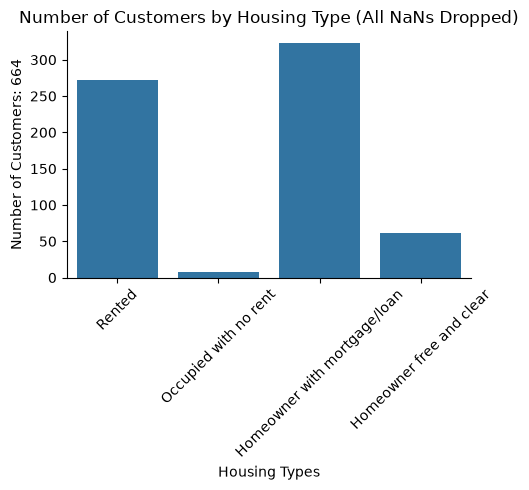

In [13]:
import seaborn as sns
sns.catplot(data=df, x="housing.type", kind="count")
plt.title("Number of Customers by Housing Type (All NaNs Dropped)")
plt.xlabel("Housing Types")
plt.ylabel("Number of Customers: 664")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### import the matplotlib library

In [14]:
import matplotlib.pyplot as plt

#### Count how many rows (customers) belong to each housing type with two functions value_counts(): loops through that column, groups the identical values together (like "Rented", "Homeowner with mortgage/loan") and counts how many rows (customers) belong to each group. sort_values() sorted by number of customers, sorts without altering the underlying data.

In [15]:
housing_counts = df["housing.type"].value_counts().sort_values(ascending=False) #sort_index()
print("housing count", housing_counts)

housing count housing.type
Homeowner with mortgage/loan    323
Rented                          272
Homeowner free and clear         61
Occupied with no rent             8
Name: count, dtype: int64


#### The bar plot uses number of customers and housing type, with labels and title.

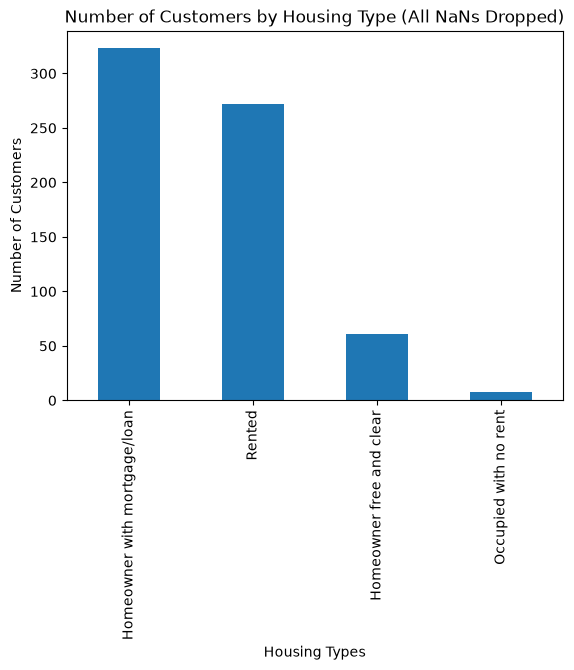

In [16]:
housing_counts.plot(kind="bar")
plt.title("Number of Customers by Housing Type (All NaNs Dropped)")
plt.xlabel("Housing Types")
plt.ylabel("Number of Customers")
#plt.xticks(rotation=45)
plt.show()

### The info reveals that 664 customers are counted in total for the bar plot.

In [17]:
df.info()

<class 'pandas.DataFrame'>
Index: 664 entries, 2 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        664 non-null    int64  
 1   sex           664 non-null    str    
 2   is.employed   664 non-null    object 
 3   income        664 non-null    int64  
 4   marital.stat  664 non-null    str    
 5   health.ins    664 non-null    bool   
 6   housing.type  664 non-null    str    
 7   recent.move   664 non-null    object 
 8   num.vehicles  664 non-null    float64
 9   age           664 non-null    float64
 10  state.of.res  664 non-null    str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 57.7+ KB


#### The bar plot shows that home owners with a mortgage are the predominant customers, reaching up to 300.  Renting is the next largest group and the smallest group are the occupants that pay no rental fee.  Next, we can assume that payments are made on a monthly basis, but for now we know that payments are being made with some form of income. The total number of customers were from info at 1000 but changed to 664 customers. (https://seaborn.pydata.org/tutorial/categorical.html#bar-plots)

## Behzad Ghabaei - End Of Lab